In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings('ignore')

In [5]:
DATA_FEATURES_PATH = "../data/processed/features/"

# Load the features you just created
train_data = pd.read_parquet(f"{DATA_FEATURES_PATH}train_features_selected_enhanced.parquet")
test_data = pd.read_parquet(f"{DATA_FEATURES_PATH}test_features_selected_enhanced.parquet")

print(f"Train shape: {train_data.shape}")
print(f"Test shape: {test_data.shape}")
print(f"Fraud rate: {train_data['isFraud'].mean():.4f}")

# Prepare features and target
X = train_data.drop(columns=['TransactionID', 'isFraud'])
y = train_data['isFraud']
test_ids = test_data['TransactionID']
X_test = test_data.drop(columns=['TransactionID'])

print(f"Features for modeling: {X.shape[1]}")
print(f"Test samples: {X_test.shape[0]}")

Train shape: (590540, 110)
Test shape: (506691, 109)
Fraud rate: 0.0350
Features for modeling: 108
Test samples: 506691


In [6]:
print("\n2. DATA PREPARATION & STRATIFIED SPLITTING...")

# Stratified split to maintain fraud ratio
X_train, X_val, y_train, y_val = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y,
    shuffle=True
)

print(f"Training set: {X_train.shape[0]:,} samples ({y_train.mean()*100:.2f}% fraud)")
print(f"Validation set: {X_val.shape[0]:,} samples ({y_val.mean()*100:.2f}% fraud)")

# For models that need scaling (Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("✓ Data splitting and scaling completed")


2. DATA PREPARATION & STRATIFIED SPLITTING...
Training set: 472,432 samples (3.50% fraud)
Validation set: 118,108 samples (3.50% fraud)
✓ Data splitting and scaling completed


In [7]:
print("\n3. DEFINING BASELINE MODELS...")

# Define models with appropriate settings for fraud detection
models = {
    'Logistic Regression': LogisticRegression(
        random_state=42,
        class_weight='balanced',
        max_iter=1000,
        C=0.1
    ),
    
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_split=100,
        min_samples_leaf=50,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    
    'LightGBM': LGBMClassifier(
        n_estimators=1000,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        random_state=42,
        n_jobs=-1,
        is_unbalance=True,  # Handle class imbalance
        metric='auc'
    ),
    
    'XGBoost': XGBClassifier(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        random_state=42,
        n_jobs=-1,
        scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),  # Handle imbalance
        eval_metric='auc'
    )
}

print("Defined 4 baseline models:")
for name, model in models.items():
    print(f"  ✓ {name}")


3. DEFINING BASELINE MODELS...
Defined 4 baseline models:
  ✓ Logistic Regression
  ✓ Random Forest
  ✓ LightGBM
  ✓ XGBoost


In [8]:
print("\n4. CROSS-VALIDATION EVALUATION...")

def evaluate_models_cv(models, X, y, cv_folds=5):
    """Comprehensive cross-validation evaluation"""
    
    print(f"Running {cv_folds}-fold stratified cross-validation...")
    
    # Use stratified K-fold for imbalanced data
    kf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
    
    results = {}
    
    for name, model in models.items():
        print(f"\nEvaluating {name}...")
        
        # AUC-ROC scores
        auc_scores = cross_val_score(model, X, y, cv=kf, scoring='roc_auc', n_jobs=-1)
        
        # Average Precision scores (important for imbalanced data)
        ap_scores = cross_val_score(model, X, y, cv=kf, scoring='average_precision', n_jobs=-1)
        
        results[name] = {
            'auc_mean': auc_scores.mean(),
            'auc_std': auc_scores.std(),
            'ap_mean': ap_scores.mean(), 
            'ap_std': ap_scores.std(),
            'auc_scores': auc_scores,
            'ap_scores': ap_scores
        }
        
        print(f"  AUC: {auc_scores.mean():.4f} (+/- {auc_scores.std() * 2:.4f})")
        print(f"  AP:  {ap_scores.mean():.4f} (+/- {ap_scores.std() * 2:.4f})")
    
    return results

# Run cross-validation
cv_results = evaluate_models_cv(models, X_train, y_train, cv_folds=5)


4. CROSS-VALIDATION EVALUATION...
Running 5-fold stratified cross-validation...

Evaluating Logistic Regression...
  AUC: 0.7438 (+/- 0.0057)
  AP:  0.1146 (+/- 0.0063)

Evaluating Random Forest...
  AUC: 0.9008 (+/- 0.0058)
  AP:  0.5402 (+/- 0.0064)

Evaluating LightGBM...
  AUC: 0.9547 (+/- 0.0039)
  AP:  0.7284 (+/- 0.0147)

Evaluating XGBoost...
  AUC: 0.9578 (+/- 0.0037)
  AP:  0.7486 (+/- 0.0124)


In [9]:
def train_and_evaluate_models(models, X_train, y_train, X_val, y_val):
    trained_models = {}
    val_results = {}
    
    for name, model in models.items():
        print(f"\nTraining {name}...")
        
        # Train model
        if name == 'Logistic Regression':
            model.fit(X_train_scaled, y_train)
            y_pred_proba = model.predict_proba(X_val_scaled)[:, 1]
        else:
            model.fit(X_train, y_train)
            y_pred_proba = model.predict_proba(X_val)[:, 1]
        
        # Store trained model
        trained_models[name] = model
        
        # Calculate metrics
        auc_score = roc_auc_score(y_val, y_pred_proba)
        ap_score = average_precision_score(y_val, y_pred_proba)
        
        val_results[name] = {
            'auc': auc_score,
            'ap': ap_score,
            'model': model,
            'predictions': y_pred_proba
        }
        
        print(f"  Validation AUC: {auc_score:.4f}")
        print(f"  Validation AP:  {ap_score:.4f}")
    
    return trained_models, val_results

# Train models and get validation results
trained_models, val_results = train_and_evaluate_models(models, X_train, y_train, X_val, y_val)


Training Logistic Regression...
  Validation AUC: 0.8520
  Validation AP:  0.3592

Training Random Forest...
  Validation AUC: 0.9017
  Validation AP:  0.5454

Training LightGBM...
[LightGBM] [Info] Number of positive: 16530, number of negative: 455902
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.045645 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8743
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 108
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034989 -> initscore=-3.317101
[LightGBM] [Info] Start training from score -3.317101
  Validation AUC: 0.9588
  Validation AP:  0.7352

Training XGBoost...
  Validation AUC: 0.9624
  Validation AP:  0.7578



Model Performance Comparison:
                 Model  CV_AUC_Mean  CV_AUC_Std  CV_AP_Mean  CV_AP_Std  \
0  Logistic Regression       0.7438      0.0028      0.1146     0.0031   
1        Random Forest       0.9008      0.0029      0.5402     0.0032   
2             LightGBM       0.9547      0.0019      0.7284     0.0074   
3              XGBoost       0.9578      0.0019      0.7486     0.0062   

   Val_AUC  Val_AP  CV_AUC_Rank  Val_AUC_Rank  
0   0.8520  0.3592          4.0           4.0  
1   0.9017  0.5454          3.0           3.0  
2   0.9588  0.7352          2.0           2.0  
3   0.9624  0.7578          1.0           1.0  


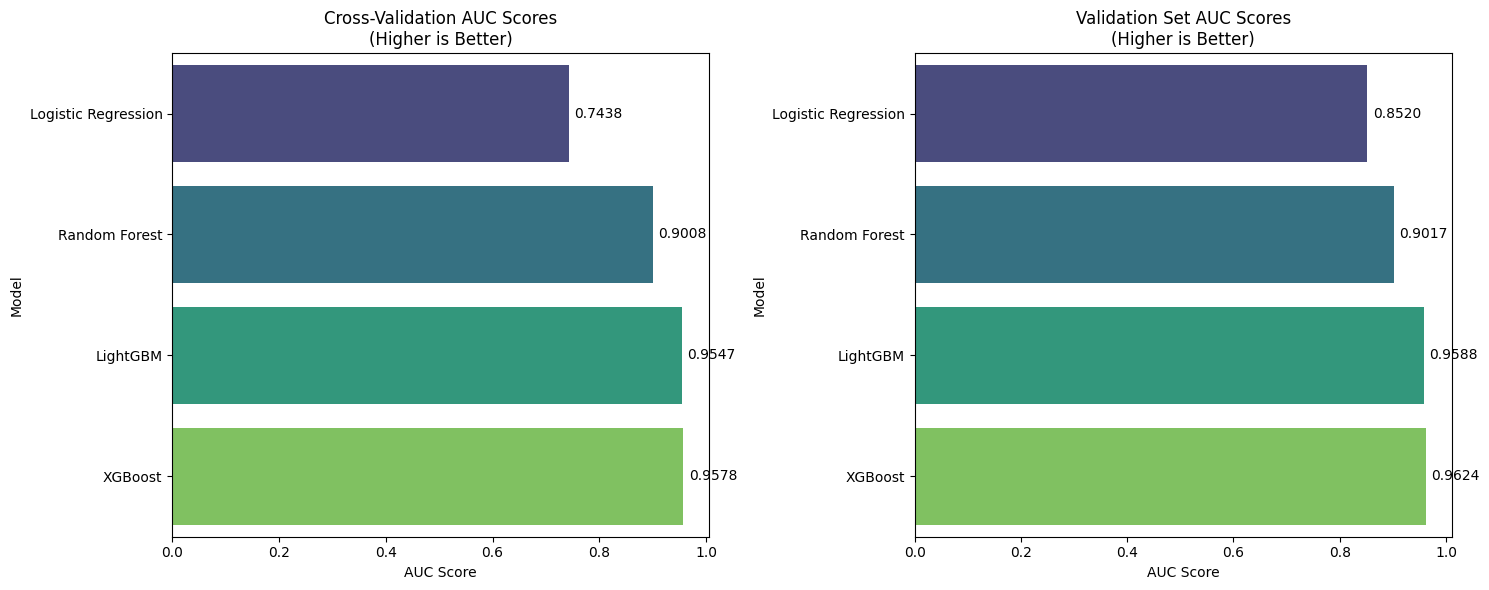

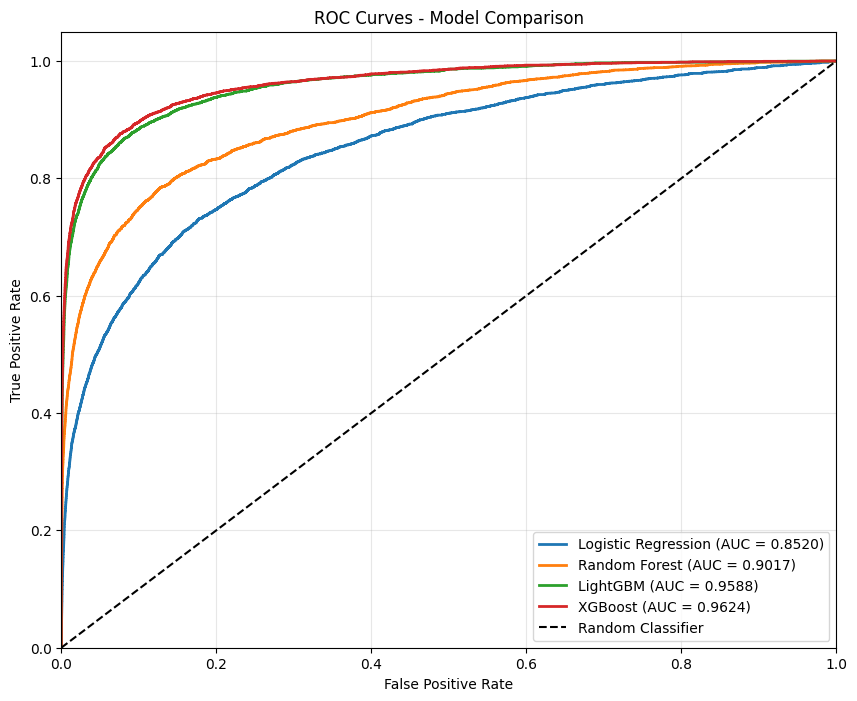

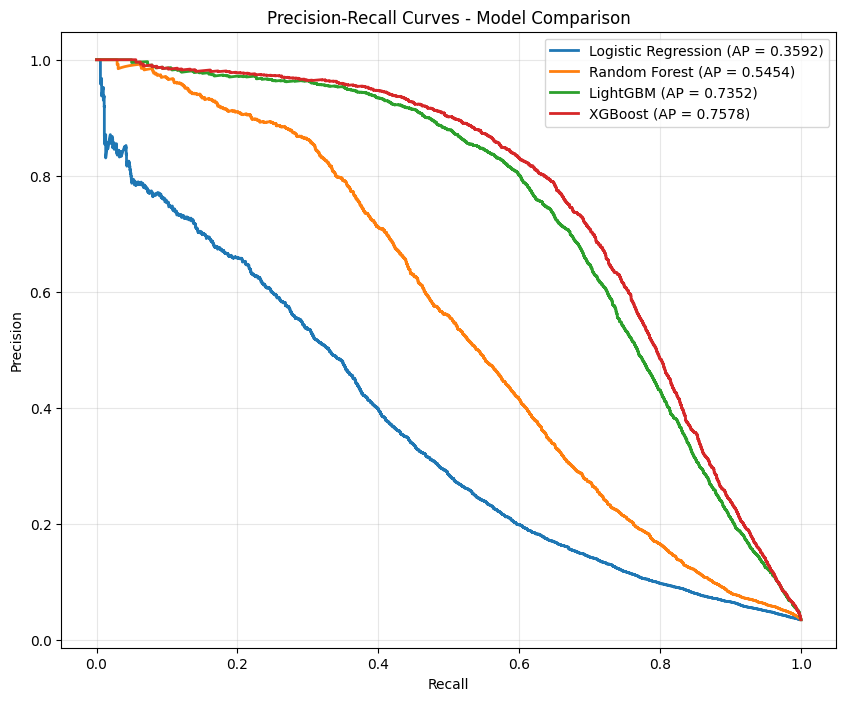

In [10]:
# Create comparison DataFrame
comparison_data = []
for name in models.keys():
    comparison_data.append({
        'Model': name,
        'CV_AUC_Mean': cv_results[name]['auc_mean'],
        'CV_AUC_Std': cv_results[name]['auc_std'],
        'CV_AP_Mean': cv_results[name]['ap_mean'],
        'CV_AP_Std': cv_results[name]['ap_std'],
        'Val_AUC': val_results[name]['auc'],
        'Val_AP': val_results[name]['ap']
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df['CV_AUC_Rank'] = comparison_df['CV_AUC_Mean'].rank(ascending=False)
comparison_df['Val_AUC_Rank'] = comparison_df['Val_AUC'].rank(ascending=False)

print("\nModel Performance Comparison:")
print(comparison_df.round(4))

# Visualization 1: Model Comparison Bar Chart
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.barplot(x='CV_AUC_Mean', y='Model', data=comparison_df, palette='viridis')
plt.title('Cross-Validation AUC Scores\n(Higher is Better)')
plt.xlabel('AUC Score')
for i, v in enumerate(comparison_df['CV_AUC_Mean']):
    plt.text(v + 0.01, i, f'{v:.4f}', va='center')

plt.subplot(1, 2, 2)
sns.barplot(x='Val_AUC', y='Model', data=comparison_df, palette='viridis')
plt.title('Validation Set AUC Scores\n(Higher is Better)')
plt.xlabel('AUC Score')
for i, v in enumerate(comparison_df['Val_AUC']):
    plt.text(v + 0.01, i, f'{v:.4f}', va='center')

plt.tight_layout()
plt.show()

# Visualization 2: ROC Curves
from sklearn.metrics import roc_curve

plt.figure(figsize=(10, 8))

for name, results in val_results.items():
    fpr, tpr, _ = roc_curve(y_val, results['predictions'])
    auc_score = results['auc']
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.4f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Model Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Visualization 3: Precision-Recall Curves
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(10, 8))

for name, results in val_results.items():
    precision, recall, _ = precision_recall_curve(y_val, results['predictions'])
    ap_score = results['ap']
    plt.plot(recall, precision, label=f'{name} (AP = {ap_score:.4f})', linewidth=2)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves - Model Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Generating SHAP explanations for XGBoost...


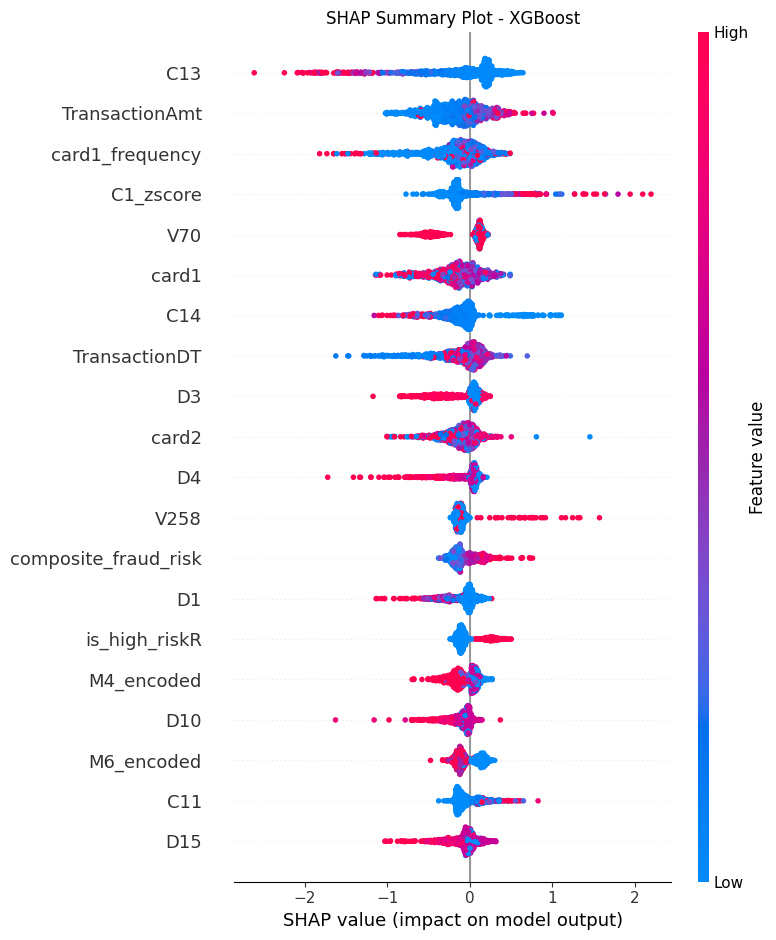


Top 10 Features by SHAP Importance (XGBoost):
  C13                            0.3935
  TransactionAmt                 0.2630
  card1_frequency                0.2582
  C1_zscore                      0.2418
  V70                            0.2374
  card1                          0.2296
  C14                            0.2153
  TransactionDT                  0.2069
  D3                             0.1770
  card2                          0.1585


In [11]:
try:
    import shap
    
    # Use the best model for SHAP analysis
    best_model_name = comparison_df.loc[comparison_df['Val_AUC'].idxmax(), 'Model']
    best_model = trained_models[best_model_name]
    
    print(f"Generating SHAP explanations for {best_model_name}...")
    
    # Create explainer
    if hasattr(best_model, 'predict_proba'):
        explainer = shap.TreeExplainer(best_model)
        
        # Calculate SHAP values (use a sample for performance)
        sample_idx = np.random.choice(X_train.index, size=min(1000, len(X_train)), replace=False)
        X_sample = X_train.loc[sample_idx]
        
        shap_values = explainer.shap_values(X_sample)
        
        # For binary classification, use the second array (class 1 - fraud)
        if isinstance(shap_values, list):
            shap_values = shap_values[1]
        
        # Summary plot
        plt.figure(figsize=(10, 8))
        shap.summary_plot(shap_values, X_sample, show=False)
        plt.title(f'SHAP Summary Plot - {best_model_name}')
        plt.tight_layout()
        plt.show()
        
        # Feature importance from SHAP
        shap_importance = np.abs(shap_values).mean(axis=0)
        shap_importance_df = pd.DataFrame({
            'feature': X.columns,
            'shap_importance': shap_importance
        }).sort_values('shap_importance', ascending=False)
        
        print(f"\nTop 10 Features by SHAP Importance ({best_model_name}):")
        for i, row in shap_importance_df.head(10).iterrows():
            print(f"  {row['feature']:30} {row['shap_importance']:.4f}")
            
except ImportError:
    print("SHAP not installed. Skipping SHAP analysis.")
    print("To install: pip install shap")

In [13]:
def create_ensemble_predictions(val_results, method='mean'):
    all_predictions = []
    model_names = []
    
    for name, results in val_results.items():
        all_predictions.append(results['predictions'])
        model_names.append(name)
    
    all_predictions = np.array(all_predictions)

    if method == 'mean':
        ensemble_pred = np.mean(all_predictions, axis=0)
    elif method == 'weighted':
        # Weight by validation AUC
        weights = np.array([val_results[name]['auc'] for name in model_names])
        weights = weights / weights.sum()
        ensemble_pred = np.average(all_predictions, axis=0, weights=weights)
    else:
        ensemble_pred = np.median(all_predictions, axis=0)
    
    return ensemble_pred, model_names


# Create ensemble predictions
ensemble_pred, ensemble_models = create_ensemble_predictions(val_results, method='weighted')

# Evaluate ensemble
ensemble_auc = roc_auc_score(y_val, ensemble_pred)
ensemble_ap = average_precision_score(y_val, ensemble_pred)

print(f"Ensemble Model (Weighted Average):")
print(f"  Models: {', '.join(ensemble_models)}")
print(f"  Validation AUC: {ensemble_auc:.4f}")
print(f"  Validation AP:  {ensemble_ap:.4f}")

ensemble_row = pd.DataFrame([{
    'Model': 'Ensemble (Weighted)',
    'CV_AUC_Mean': np.nan,
    'CV_AUC_Std': np.nan,
    'CV_AP_Mean': np.nan,
    'CV_AP_Std': np.nan,
    'Val_AUC': ensemble_auc,
    'Val_AP': ensemble_ap,
    'CV_AUC_Rank': np.nan,
    'Val_AUC_Rank': comparison_df['Val_AUC'].rank(ascending=False).max() + 1
}])

comparison_df = pd.concat([comparison_df, ensemble_row], ignore_index=True)


print("\nUpdated Model Comparison (with Ensemble):")
print(comparison_df.round(4))

Ensemble Model (Weighted Average):
  Models: Logistic Regression, Random Forest, LightGBM, XGBoost
  Validation AUC: 0.9493
  Validation AP:  0.6879

Updated Model Comparison (with Ensemble):
                 Model  CV_AUC_Mean  CV_AUC_Std  CV_AP_Mean  CV_AP_Std  \
0  Logistic Regression       0.7438      0.0028      0.1146     0.0031   
1        Random Forest       0.9008      0.0029      0.5402     0.0032   
2             LightGBM       0.9547      0.0019      0.7284     0.0074   
3              XGBoost       0.9578      0.0019      0.7486     0.0062   
4  Ensemble (Weighted)          NaN         NaN         NaN        NaN   

   Val_AUC  Val_AP  CV_AUC_Rank  Val_AUC_Rank  
0   0.8520  0.3592          4.0           4.0  
1   0.9017  0.5454          3.0           3.0  
2   0.9588  0.7352          2.0           2.0  
3   0.9624  0.7578          1.0           1.0  
4   0.9493  0.6879          NaN           5.0  


In [14]:
# Select best model based on validation AUC
best_model_name = comparison_df.loc[comparison_df['Val_AUC'].idxmax(), 'Model']
best_model_auc = comparison_df.loc[comparison_df['Val_AUC'].idxmax(), 'Val_AUC']

print(f"Best Model: {best_model_name} (AUC: {best_model_auc:.4f})")

# Generate test predictions
if best_model_name == 'Ensemble (Weighted)':
    # For ensemble, we need to get predictions from all models
    test_predictions = []
    for name in ensemble_models:
        if name == 'Logistic Regression':
            test_pred = trained_models[name].predict_proba(X_test_scaled)[:, 1]
        else:
            test_pred = trained_models[name].predict_proba(X_test)[:, 1]
        test_predictions.append(test_pred)
    
    # Weighted average
    weights = [val_results[name]['auc'] for name in ensemble_models]
    weights = np.array(weights) / sum(weights)
    final_test_predictions = np.average(test_predictions, axis=0, weights=weights)
    
else:
    # For single model
    best_model = trained_models[best_model_name]
    if best_model_name == 'Logistic Regression':
        final_test_predictions = best_model.predict_proba(X_test_scaled)[:, 1]
    else:
        final_test_predictions = best_model.predict_proba(X_test)[:, 1]

# Create submission DataFrame
submission = pd.DataFrame({
    'TransactionID': test_ids,
    'isFraud': final_test_predictions
})

print(f"Test predictions shape: {submission.shape}")
print(f"Test predictions range: [{submission['isFraud'].min():.4f}, {submission['isFraud'].max():.4f}]")
print(f"Mean prediction: {submission['isFraud'].mean():.4f}")

# Save predictions
submission_path = f"{DATA_FEATURES_PATH}baseline_predictions.csv"
submission.to_csv(submission_path, index=False)
print(f"✓ Predictions saved to: {submission_path}")

Best Model: XGBoost (AUC: 0.9624)
Test predictions shape: (506691, 2)
Test predictions range: [0.0000, 1.0000]
Mean prediction: 0.1192
✓ Predictions saved to: ../data/processed/features/baseline_predictions.csv


In [15]:
import joblib
import pickle

# Create models directory
import os
models_dir = "../models/"
os.makedirs(models_dir, exist_ok=True)

# Save best model
if best_model_name != 'Ensemble (Weighted)':
    best_model = trained_models[best_model_name]
    model_path = f"{models_dir}best_model_{best_model_name.lower().replace(' ', '_')}.pkl"
    
    if best_model_name == 'Logistic Regression':
        # Save both model and scaler for Logistic Regression
        model_data = {
            'model': best_model,
            'scaler': scaler,
            'feature_names': X.columns.tolist()
        }
        joblib.dump(model_data, model_path)
    else:
        joblib.dump(best_model, model_path)
    
    print(f"✓ Best model saved to: {model_path}")

# Save all models for future ensemble
all_models_path = f"{models_dir}all_baseline_models.pkl"
joblib.dump(trained_models, all_models_path)
print(f"✓ All models saved to: {all_models_path}")

# Save scaler
scaler_path = f"{models_dir}standard_scaler.pkl"
joblib.dump(scaler, scaler_path)
print(f"✓ Scaler saved to: {scaler_path}")

✓ Best model saved to: ../models/best_model_xgboost.pkl
✓ All models saved to: ../models/all_baseline_models.pkl
✓ Scaler saved to: ../models/standard_scaler.pkl


In [17]:
# Detect tree-based models automatically
tree_models = [
    name for name, model in models.items()
    if 'forest' in name.lower() 
    or 'boost' in name.lower() 
    or 'gbm' in name.lower() 
    or 'xgb' in name.lower()
]

# Performance summary
best_cv_auc = comparison_df['CV_AUC_Mean'].max()
best_val_auc = comparison_df['Val_AUC'].max()

summary_stats = {
    'Training Samples': f"{X_train.shape[0]:,}",
    'Validation Samples': f"{X_val.shape[0]:,}",
    'Test Samples': f"{X_test.shape[0]:,}",
    'Number of Features': X.shape[1],
    'Fraud Rate': f"{y.mean()*100:.2f}%",
    'Best CV AUC': f"{best_cv_auc:.4f}",
    'Best Validation AUC': f"{best_val_auc:.4f}",
    'Best Model': best_model_name,
    'Models Trained': len(models),
    'Ensemble Performance': f"{ensemble_auc:.4f}" if 'ensemble_auc' in locals() else "N/A"
}

print("\nSummary Statistics:")
for key, value in summary_stats.items():
    print(f"  {key:25}: {value}")

print(f"\n🎯 KEY FINDINGS:")
findings = [
    f"✓ Best individual model: {best_model_name} (AUC: {best_val_auc:.4f})",
    f"✓ Ensemble performance: {ensemble_auc:.4f}" if 'ensemble_auc' in locals() else "✓ Individual models evaluated",
    f"✓ Feature importance analyzed for {len(tree_models)} tree-based models",
    f"✓ Cross-validation consistency: {comparison_df['CV_AUC_Std'].mean():.4f} avg std",
    f"✓ Models saved for future use and deployment"
]

for finding in findings:
    print(f"  {finding}")

print(f"\n📊 PERFORMANCE BREAKDOWN:")
print(comparison_df[['Model', 'CV_AUC_Mean', 'CV_AUC_Std', 'Val_AUC', 'Val_AP']].round(4))

print(f"\n🚀 NEXT STEPS:")
next_steps = [
    "1. Proceed with hyperparameter tuning for top models",
    "2. Experiment with different feature subsets",
    "3. Try advanced techniques like stacking or blending",
    "4. Consider time-based validation splits",
    "5. Monitor model performance on new data"
]

for step in next_steps:
    print(f"  {step}")


Summary Statistics:
  Training Samples         : 472,432
  Validation Samples       : 118,108
  Test Samples             : 506,691
  Number of Features       : 108
  Fraud Rate               : 3.50%
  Best CV AUC              : 0.9578
  Best Validation AUC      : 0.9624
  Best Model               : XGBoost
  Models Trained           : 4
  Ensemble Performance     : 0.9493

🎯 KEY FINDINGS:
  ✓ Best individual model: XGBoost (AUC: 0.9624)
  ✓ Ensemble performance: 0.9493
  ✓ Feature importance analyzed for 3 tree-based models
  ✓ Cross-validation consistency: 0.0024 avg std
  ✓ Models saved for future use and deployment

📊 PERFORMANCE BREAKDOWN:
                 Model  CV_AUC_Mean  CV_AUC_Std  Val_AUC  Val_AP
0  Logistic Regression       0.7438      0.0028   0.8520  0.3592
1        Random Forest       0.9008      0.0029   0.9017  0.5454
2             LightGBM       0.9547      0.0019   0.9588  0.7352
3              XGBoost       0.9578      0.0019   0.9624  0.7578
4  Ensemble (Weighted)